# Implement folder Planck equation
Work on hi and si

In [1]:
import numpy as np


In [2]:
p_let=0.05
p_aa=0.05
p_sil=0.9
mu_M=-0.5
sigma_M=0.3
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
E_a=2                         # Ag-gate threshold
kBT=1.0                         # thermal factor
N_i=2500  
N_max=2500
mu_i=0.0 
sigma_i=0.5
p_diff=0.10
    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=None,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=2500,  N_max=2500,
    # grid / time ----------------------------------------------------------
    h_min=-7.0, h_max=7.0, d_h=0.1,
    T=10.0,  dt=0.01,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h


    print('D=',D)

    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  = (C_broad * eE).sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)





# Same antigen

D= 0.017202216066481996
    1  t=  0.01  N=  2500.0  Ω=  0.000  ⟨Γ⟩=  -0.689  ⟨h_1⟩=  0.00  ⟨h_2⟩=  0.00
    2  t=  0.02  N=  2482.6  Ω=  0.000  ⟨Γ⟩=  -0.687  ⟨h_1⟩=  0.00  ⟨h_2⟩=  0.00
    3  t=  0.03  N=  2465.3  Ω=  0.000  ⟨Γ⟩=  -0.685  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    4  t=  0.04  N=  2448.2  Ω=  0.000  ⟨Γ⟩=  -0.683  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    5  t=  0.05  N=  2431.3  Ω=  0.000  ⟨Γ⟩=  -0.681  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    6  t=  0.06  N=  2414.6  Ω=  0.000  ⟨Γ⟩=  -0.678  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    7  t=  0.07  N=  2398.0  Ω=  0.000  ⟨Γ⟩=  -0.676  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    8  t=  0.08  N=  2381.6  Ω=  0.000  ⟨Γ⟩=  -0.674  ⟨h_1⟩=  0.01  ⟨h_2⟩=  0.01
    9  t=  0.09  N=  2365.4  Ω=  0.000  ⟨Γ⟩=  -0.672  ⟨h_1⟩=  0.02  ⟨h_2⟩=  0.02
   10  t=  0.10  N=  2349.3  Ω=  0.000  ⟨Γ⟩=  -0.670  ⟨h_1⟩=  0.02  ⟨h_2⟩=  0.02
   11  t=  0.11  N=  2333.4  Ω=  0.000  ⟨Γ⟩=  -0.668  ⟨h_1⟩=  0.02  ⟨h_2⟩=  0.02
   12  t=  0.12  N=  2317.7  Ω=  0.000  ⟨Γ⟩=  -0.665  ⟨h_1⟩=  0.02  ⟨h_2⟩=  0.02
   1

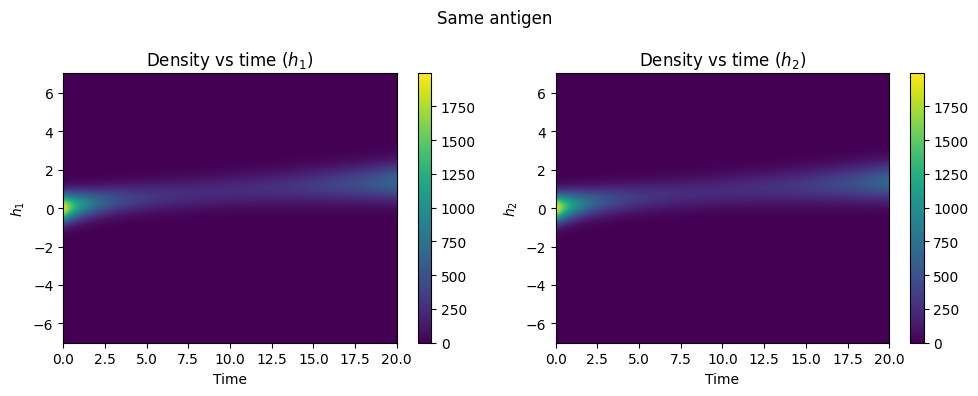

In [24]:
S_mat = np.array([[1],   # h1
                  [1],
                  ],  # h2
                 dtype=float)         
k=S_mat.shape[0]
def get_C(t,v):
    return 5.0

axes,times,rho_t, omegas=fp_density_time_series_kD(S_mat=S_mat,get_C=get_C, verbose=True, T=20)
print('rhot',rho_t.shape)
print('times',times.shape)

print('omegas',omegas.shape)

# ---------------- plotting evolution per dimension ---------------
fig, axs = plt.subplots(1, k, figsize=(10, 4), sharex=True)

# Détermine masque global : points qui ont densité positive au moins une fois
rho_sum_over_time = rho_t.max(axis=0)   # shape = (m, m, …, m)
mask = rho_sum_over_time > 0            # bool grid

# Pour chaque axe h_i, on trouve les indices non nuls
for dim in range(k):
    # Intégrer sur toutes les autres dimensions
    axes_other = [i for i in range(k) if i != dim]
    rho_marg = rho_t
    for ax in sorted(axes_other, reverse=True):
        rho_marg = rho_marg.sum(axis=ax+1)  # time axis 0 → offset +1

    rho_marg *= (axes[0][1] - axes[0][0])**(k - 1)

    # Bornes y : où mask est True le long de dim
    mask_dim = mask.any(axis=tuple(i for i in range(k) if i != dim))
    idx = np.where(mask_dim)[0]
    if len(idx) == 0:
        y_min, y_max = axes[dim][0], axes[dim][-1]
    else:
        y_min, y_max = axes[dim][idx[0]], axes[dim][idx[-1]]

    im = axs[dim].imshow(rho_marg.T, origin='lower', aspect='auto',
                         extent=[times[0], times[-1], y_min, y_max])
    axs[dim].set_xlabel("Time")
    axs[dim].set_ylabel(fr"$h_{dim+1}$")
    axs[dim].set_title(f"Density vs time ($h_{dim+1}$)")
    fig.colorbar(im, ax=axs[dim])
fig.suptitle("Same antigen")

plt.tight_layout()
plt.show()


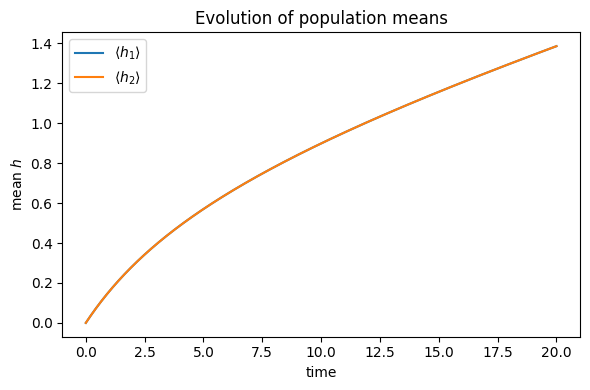

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------------------------------------------
# 0.  Expectation: the user has just executed
#    axes, times, rho_t, omegas = fp_density_time_series_kD(...)
# -------------------------------------------------------------------
try:
    axes, times, rho_t
except NameError as e:
    raise RuntimeError("Run fp_density_time_series_kD first to define "
                       "axes, times, rho_t, omegas") from e

N_h = len(axes)
assert N_h >= 2, "Need at least two shape components (h1, h2)"

# -------------------------------------------------------------------
# 1.  Compute mean ⟨h1⟩ and ⟨h2⟩  over the population at each snapshot
# -------------------------------------------------------------------
d_h = axes[0][1] - axes[0][0]         # uniform grid spacing
dH  = d_h ** N_h                      # hyper‐voxel volume

# coordinate mesh
h_mesh = np.meshgrid(*axes, indexing="ij")     # list length N_h

mean_h1 = []
mean_h2 = []

for rho in rho_t:
    N_pop    = rho.sum() * dH
    mean_h1.append((rho * h_mesh[0]).sum() * dH / N_pop)
    mean_h2.append((rho * h_mesh[1]).sum() * dH / N_pop)

mean_h1 = np.asarray(mean_h1)
mean_h2 = np.asarray(mean_h2)

# -------------------------------------------------------------------
# 2.  Plot the trajectories
# -------------------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(times, mean_h1, label=r'$\langle h_1\rangle$')
plt.plot(times, mean_h2, label=r'$\langle h_2\rangle$')
plt.xlabel("time")
plt.ylabel("mean $h$")
plt.title("Evolution of population means")
plt.legend()
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3.  Interactive table for inspection
# -------------------------------------------------------------------
df = pd.DataFrame({"time": times,
                   "mean_h1": mean_h1,
                   "mean_h2": mean_h2})



In [26]:
import numpy as np
import matplotlib.pyplot as plt

# times and mean_h1 must already exist and have identical length
assert len(times) == len(mean_h1), "times and mean_h1 length mismatch"
dt = times[1] - times[0]                        # uniform spacing assumed

# 1. derivative via finite difference
eps = mean_h1
n   = len(eps)
eps_dot = np.empty_like(eps)

# end points: 2-point forward / backward
eps_dot[0]   = (eps[1]   - eps[0])   / dt
eps_dot[-1]  = (eps[-1]  - eps[-2])  / dt

# interior points: 3-point centred stencil
eps_dot[1:-1] = (eps[2:] - eps[:-2]) / (2*dt)




In [27]:
import numpy as np
import matplotlib.pyplot as plt

# -- assume `times` and `mean_h1` are already defined and same length --
t   = np.asarray(times,   dtype=float)
eps = np.asarray(mean_h1, dtype=float)
dt  = t[1] - t[0]                         # uniform spacing
n   = len(t)

# container
eps_ddot = np.empty_like(eps)

# ---- lower-order 3-point at the first two and last two nodes ----------
eps_ddot[0]  = (eps[2]   - 2*eps[1]  + eps[0])   / dt**2
eps_ddot[1]  = (eps[3]   - 2*eps[2]  + eps[1])   / dt**2
eps_ddot[-2] = (eps[-2]  - 2*eps[-3] + eps[-4])  / dt**2
eps_ddot[-1] = (eps[-1]  - 2*eps[-2] + eps[-3])  / dt**2

# ---- 5-point centred stencil for interior  k = 2 … n−3  ---------------
k_slice = slice(2, n-2)                   # indices 2 … n−3
eps_ddot[k_slice] = (
      -eps[4:]    + 16*eps[3:-1] - 30*eps[2:-2]
    + 16*eps[1:-3] -   eps[0:-4]
) / (12*dt**2)




In [28]:
import numpy as np
import torch

# ---------------------------------------------------------------------
# 0.  Objects already in memory from your simulation / analysis
# ---------------------------------------------------------------------
#   S_mat      – motif matrix  (N_h, n_A)
#   get_C      – concentration schedule   C_v(t)
#   times      – snapshot times           (len = n_snaps)
#   rho_t      – density snapshots        (n_snaps, …grid…)
#   omegas     – Ω(t) array               (n_snaps,)
#   mean_h1    – ⟨h₁⟩(t_k)                (n_snaps,)
#   mean_h2    – ⟨h₂⟩(t_k)                (n_snaps,)
#   … (other ⟨h_i⟩ if N_h>2) …
# ---------------------------------------------------------------------

# if dimension N_h>2, collect all means in one (n_snaps, N_h) array
mean_h = np.vstack([mean_h1, mean_h2]).T      # extend with extra  rows if needed

# constants from the model header
# p_let, p_diff = 0.15, 0.10

# E_a, kBT  = 0.0, 1.0
# p_aa, p_sil = 0.10, 0.75
# f_aa     = p_aa / (p_aa + p_sil)
# f_sil    = 1.0 - f_aa
# sigma_M, mu_M = 0.1, 0.0
# D        = f_aa * (sigma_M**2 + f_sil * mu_M**2)  # not used here, just FYI

# ---------------------------------------------------------------------
# 1.  Pre-compute Φ̄(t_k)  exactly like in fp_density_time_series_kD
# ---------------------------------------------------------------------
N_h, n_A   = S_mat.shape
h_axes     = tuple(np.asarray(ax) for ax in axes)
d_h        = h_axes[0][1] - h_axes[0][0]
dH         = d_h ** N_h

h_mesh     = np.meshgrid(*h_axes, indexing="ij")
E_full     = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

Phi_bar = np.zeros_like(times, dtype=float)
for k, t_now in enumerate(times):
    C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)])
    C_brd  = C_vec.reshape((n_A,) + (1,)*N_h)
    Phi    = (C_brd * np.exp(E_full / kBT)).sum(axis=0)
    rho    = rho_t[k]
    N_pop  = rho.sum() * dH
    Phi_bar[k] = (rho * Phi).sum() * dH / N_pop

# ---------------------------------------------------------------------
# 2.  Torch version of Γ(h,t)  + its gradient wrt h
# ---------------------------------------------------------------------
device   = torch.device("cpu")
S_torch  = torch.tensor(S_mat, dtype=torch.float64, device=device)

def gamma_torch(h_vec_t,                          # shape (N_h,)
                t_idx: int):                      # snapshot index
    t_now = float(times[t_idx])

    # concentration vector C_v(t_k)
    C_vec = torch.tensor([get_C(t_now, v) for v in range(n_A)],
                         dtype=torch.float64, device=device)

    # Ω and Φ̄ for this time
    omega_k   = float(omegas[t_idx])
    Phi_bar_k = float(Phi_bar[t_idx])

    # binding energies  E_v(h) = h · s_{·,v}
    E_v = torch.mv(S_torch.T, h_vec_t)            # (n_A,)

    # gates ------------------------------------------------------------
    P_Ag_num = (C_vec * torch.exp((E_v - E_a) / kBT)).sum()
    P_Ag     = P_Ag_num / (1.0 + P_Ag_num)

    Phi      = (C_vec * torch.exp(E_v / kBT)).sum()
    P_T      = Phi / (Phi + Phi_bar_k / C_vec.sum())

    return lam + torch.log(P_Ag) + torch.log(P_T) + omega_k

# ---------------------------------------------------------------------
# 3.  dΓ/dh₁ along the mean-path  h̄(t_k)
# ---------------------------------------------------------------------
dGamma_dh1 = np.zeros_like(times, dtype=float)

for k in range(len(times)):
    h_vec_np = mean_h[k]                           # (N_h,)
    h_t = torch.tensor(h_vec_np,
                       dtype=torch.float64,
                       device=device,
                       requires_grad=True)
    gamma_torch(h_t, k).backward()
    dGamma_dh1[k] = h_t.grad[0].item()             # first coordinate

# ---------------------------------------------------------------------



In [29]:
# plt.figure(figsize=(6,4))
# plt.plot(times, dGamma_dh1, label=r'$\partial\Gamma/\partial h_1$ along ⟨h⟩(t)')
# plt.plot(times, -eps_ddot/D, label=r'$\partial\Gamma/\partial h_1$ along ⟨h⟩(t)')

# plt.xlabel('time')
# plt.ylabel(r'$\partial\Gamma/\partial h_1$')
# plt.title('dΓ/dh₁ evaluated at the population mean')
# plt.legend()
# plt.tight_layout()
# plt.show()

In [30]:
def gamma(ee, omega,
          *,                             # all following parameters are keyword-only
          C_vec,                         # shape (n_A,) – antigen surface concentrations at t
          lam,                           # λ = log 2 + log(1−p_let) + log(1−p_diff)
          E_a,                           # Ag-internalisation threshold
          kBT,                           # thermal factor
          Phi_bar,                       # population-averaged Φ̄(t)
          C_tot):                        # total concentration Σ_v C_v
    """
    Compute the net growth/decay rate Γ(h,t) for a single point h on the grid.

    Parameters
    ----------
    ee : ndarray, shape (n_A,)
        Binding energies E_v(h) for all antigens v at the current point.
    omega : float
        Global regulation term Ω(t) (0 if population size < N_max).
    C_vec : ndarray, shape (n_A,)
        Instantaneous antigen concentrations C_v(t).
    lam : float
        Baseline replication–death term λ.
    E_a : float
        Threshold entering the Ag-internalisation gate.
    kBT : float
        Thermal factor (Boltzmann constant × absolute temperature).
    Phi_bar : float
        Population-averaged Φ̄(t) = ⟨Σ_v C_v e^{E_v/kBT}⟩.
    C_tot : float
        Total antigen concentration Σ_v C_v(t).

    Returns
    -------
    gamma_val : float
        Γ(h,t) = λ + log P_Ag + log P_T + Ω.
    """
    # Antigen-internalisation gate P_Ag(h,t)
    exp_term = np.exp((ee - E_a) / kBT)            # e^{(E_v−E_a)/kBT}
    numer_PAg = np.sum(C_vec * exp_term)           # Σ_v C_v e^{(E_v−E_a)/kBT}
    P_Ag = numer_PAg / (1.0 + numer_PAg)

    # T-cell help gate P_T(h,t)
    Phi = np.sum(C_vec * np.exp(ee / kBT))         # Σ_v C_v e^{E_v/kBT}
    P_T = Phi / (Phi + Phi_bar / C_tot)            # Eq. (PT definition)

    # Net growth/decay rate Γ(h,t)
    gamma_val = lam + np.log(P_Ag) + np.log(P_T) + omega
    return gamma_val


Snapshot time: t = 0.000
Population size N(t): 2500.0
Computed Φ̄(t): 6.420127


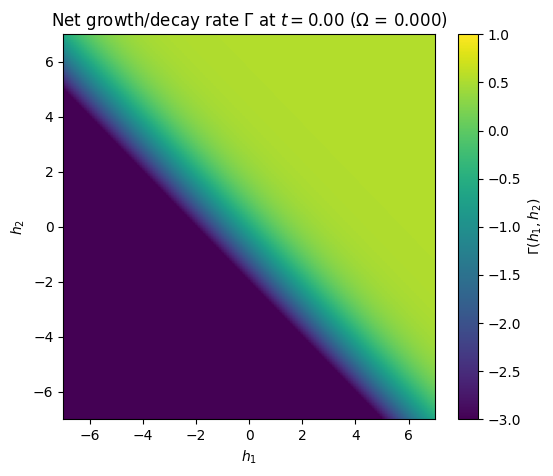

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Assumptions: the following objects already exist from the simulation
#              (they come out of fp_density_time_series_kD):
#   * axes         – tuple of length N_h with 1-D grids (h-axes)
#   * times        – 1-D array with snapshot times
#   * rho_t        – array with shape (n_snapshots, …grid…)
#   * omegas       – Ω(t) at each snapshot
#   * S_mat        – (N_h, n_A) binary motif matrix (same as used in sim)
#   * get_C(t,v)   – user-supplied concentration schedule (same as in sim)
#
# If you ran the simulation in the same notebook cell, nothing else
# needs to be changed.  Otherwise, run fp_density_time_series_kD first.
# ----------------------------------------------------------------------

# ------------------- choose a time point ------------------------------
t_plot = 0.0                                # seconds (adjust as you like)
idx = int(np.argmin(np.abs(times - t_plot))) # nearest snapshot index
t_actual = times[idx]

rho   = rho_t[idx]                           # population density ρ(h,t)
omega = omegas[idx]                          # corresponding Ω(t)

# ------------------- geometry & constants -----------------------------
h_axes = axes                                # tuple of 1-D grids
N_h    = len(h_axes)
h_axis = h_axes[0]
d_h    = h_axis[1] - h_axis[0]               # grid spacing (uniform)
dH     = d_h ** N_h                          # grid-cell volume element

h_mesh = np.meshgrid(*h_axes, indexing="ij") # list, len = N_h

n_A    = S_mat.shape[1]

# biological constants (same as in simulation)


# ------------------- binding energies ---------------------------------
# E_stack[v, ...] = E_v(h)  for every grid point
E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

# ------------------- antigen concentrations ---------------------------
C_vec = np.array([get_C(t_actual, v) for v in range(n_A)], dtype=float)
C_tot = C_vec.sum()

C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

# ------------------- Φ(h) and Φ̄(t)  -----------------------------------
Phi = np.sum(C_broad * np.exp(E_stack / kBT), axis=0)   # Σ_v C_v e^{E_v/kBT}

N_pop   = rho.sum() * dH
Phi_bar = (rho * Phi).sum() * dH / N_pop

print(f"Snapshot time: t = {t_actual:.3f}")
print(f"Population size N(t): {N_pop:.1f}")
print(f"Computed Φ̄(t): {Phi_bar:.6f}")

# ------------------- gates and Γ(h) -----------------------------------
# P_Ag
exp_term = np.exp((E_stack - E_a) / kBT)
numer_PAg = np.sum(C_broad * exp_term, axis=0)
P_Ag = numer_PAg / (1.0 + numer_PAg)

# P_T
P_T = Phi / (Phi + Phi_bar / C_tot)

# Γ(h)  (Ω already from simulation)
Gamma = lam + np.log(P_Ag) + np.log(P_T) + omega

# ------------------- plot for N_h = 2 ---------------------------------
if N_h != 2:
    raise ValueError("The heat-map visualisation below is only for N_h = 2")

h_min, h_max = h_axis[0], h_axis[-1]
plt.figure(figsize=(6, 5))
im = plt.imshow(
    Gamma,
    extent=[h_min, h_max, h_min, h_max],
    origin="lower",
    aspect="auto",
    vmin=-3,   # lower bound of color scale
    vmax=1     # upper bound of color scale
)

plt.colorbar(im, label=r'$\Gamma(h_1,h_2)$')
plt.xlabel(r'$h_1$')
plt.ylabel(r'$h_2$')
plt.title(rf'Net growth/decay rate $\Gamma$ at $t = {t_actual:.2f}$ (Ω = {omega:.3f})')
plt.show()


<bound method NDFrame.head of           t     Phi_bar  Omega
0      0.00    6.420127    0.0
1      0.01    6.441280    0.0
2      0.02    6.462452    0.0
3      0.03    6.483644    0.0
4      0.04    6.504854    0.0
...     ...         ...    ...
1996  19.96  101.164516    0.0
1997  19.97  101.257009    0.0
1998  19.98  101.349575    0.0
1999  19.99  101.442214    0.0
2000  20.00  101.534926    0.0

[2001 rows x 3 columns]>


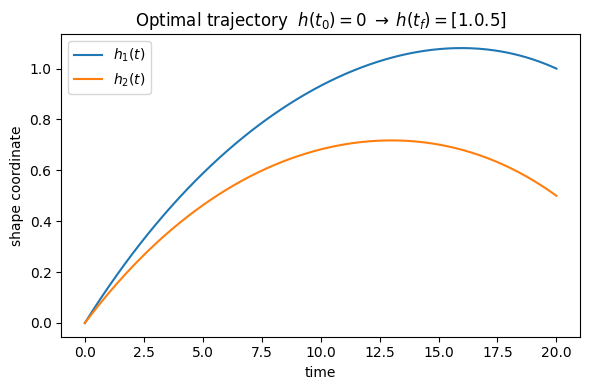

In [32]:
# ==============================================================
#  solve_optimal_trajectory(hf)
#  --------------------------------------------------------------
#  hf : scalar     → same target for both h₁,h₂
#       or length-2 iterable  → independent targets
#  returns a scipy BVP object (sol) and plots h₁,h₂ versus time
# ==============================================================

from scipy.integrate import solve_bvp
import numpy as np
import matplotlib.pyplot as plt


import numpy as np
import torch
from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1.  Φ̄(t)  ---------------------------------------------------
# ------------------------------------------------------------
N_h     = len(axes)
h_axis  = axes[0]
d_h     = h_axis[1] - h_axis[0]
dH      = d_h**N_h
n_snaps = len(times)
n_A     = S_mat.shape[1]

h_mesh  = np.meshgrid(*axes, indexing="ij")   # fixed cart. grid

Phi_bar_list = []

for idx, t_now in enumerate(times):
    rho_now = rho_t[idx]

    # E_v(h) on the entire grid
    E_stack = np.tensordot(S_mat.T,
                           np.stack(h_mesh, axis=0),
                           axes=(1, 0))                       # (n_A, …grid…)

    # C_v(t)
    C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)])
    C_br   = C_vec.reshape((n_A,) + (1,) * N_h)

    # Φ(h) and Φ̄(t)
    Phi     = np.sum(C_br * np.exp(E_stack / kBT), axis=0)
    N_pop   = rho_now.sum() * dH
    Phi_bar = (rho_now * Phi).sum() * dH / N_pop
    Phi_bar_list.append(Phi_bar)

# Pretty print
df = pd.DataFrame({"t": times, "Phi_bar": Phi_bar_list, "Omega": omegas})
print(df.head)
# ------------------------------------------------------------
# 2.  Γ(h,t) in PyTorch  (+ autograd gradient) ----------------
# ------------------------------------------------------------
device = torch.device("cpu")



# Torch constants that never change
S_mat_t = torch.tensor(S_mat, dtype=torch.float64, device=device)

def build_gamma_and_grad(idx):
    """
    For snapshot `idx` return:
      * gamma_torch(h_vec)      – scalar Γ(h) as torch tensor
      * grad_gamma_np(h_np)     – ∇Γ as NumPy vector
    """
    t_now      = float(times[idx])
    Phi_bar    = float(Phi_bar_list[idx])
    omega_now  = float(omegas[idx])
    C_vec      = np.array([get_C(t_now, v) for v in range(n_A)])
    C_vec_t    = torch.tensor(C_vec, dtype=torch.float64, device=device)

    def gamma_torch(h_vec_t):
        """h_vec_t: 1-D torch tensor of length N_h (requires_grad possible)"""
        E_v = torch.mv(S_mat_t.T, h_vec_t)                  # (n_A,)
        P_Ag_num = (C_vec_t * torch.exp((E_v - E_a)/kBT)).sum()
        P_Ag     = P_Ag_num / (1. + P_Ag_num)

        Phi  = (C_vec_t * torch.exp(E_v / kBT)).sum()
        P_T  = Phi / (Phi + Phi_bar / C_vec_t.sum())

        return lam + torch.log(P_Ag) + torch.log(P_T) + omega_now

    def grad_gamma_np(h_np):
        h_t = torch.tensor(h_np, dtype=torch.float64,
                           device=device, requires_grad=True)
        g   = gamma_torch(h_t)
        g.backward()                       # autograd
        return h_t.grad.cpu().numpy()

    return gamma_torch, grad_gamma_np

gamma_list, grad_list = zip(*[build_gamma_and_grad(i) for i in range(n_snaps)])
# -------- handy wrapper around grad_list ----------------------
def grad_Gamma(h_vec, t_scalar):
    """
    Linear interpolation of ∇Γ between stored snapshots.
    h_vec : (2,) numpy   t_scalar : float
    """
    if t_scalar <= times[0]:
        return grad_list[0](h_vec)
    if t_scalar >= times[-1]:
        return grad_list[-1](h_vec)

    hi = np.searchsorted(times, t_scalar)
    lo = hi - 1
    w  = (t_scalar - times[lo]) / (times[hi] - times[lo])
    return (1.-w) * grad_list[lo](h_vec) + w * grad_list[hi](h_vec)

# -------- main solver function --------------------------------
def solve_optimal_trajectory(hf, plot=False):
    hf = np.repeat(hf, 2) if np.isscalar(hf) else np.asarray(hf, float)
    assert hf.size == 2, "hf must be scalar or length-2 iterable"

    # ODE y = [h₁,h₂,v₁,v₂]
    def ode(t, y):
        h = y[:2, :]
        v = y[2:, :]
        dhdt = v
        dvdt = np.empty_like(h)
        for j, tj in enumerate(t):
            dvdt[:, j] = -D * grad_Gamma(h[:, j], tj)
        return np.vstack((dhdt, dvdt))

    def bc(ya, yb):
        # h(t0)=0 , h(tf)=hf
        return np.hstack((ya[:2], yb[:2] - hf))

    # time mesh & linear initial guess
    t0, tf = times[0], times[-1]
    t_mesh = np.linspace(t0, tf, 300)
    y_guess = np.zeros((4, t_mesh.size))
    for i in range(2):
        y_guess[i] = hf[i] * (t_mesh - t0) / (tf - t0)

    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=20000)
    if not sol.success:
        raise RuntimeError(sol.message)

    # ---------- plot
    if plot:
        plt.figure(figsize=(6,4))
        plt.plot(sol.x, sol.y[0], label=r'$h_1(t)$')
        plt.plot(sol.x, sol.y[1], label=r'$h_2(t)$')
        plt.xlabel('time')
        plt.ylabel('shape coordinate')
        plt.title(fr'Optimal trajectory  $h(t_0)=0\;\to\;h(t_f)={hf}$')
        plt.legend(); plt.tight_layout(); plt.show()

    return sol

# ==============================================================
# EXAMPLE
# ==============================================================
sol = solve_optimal_trajectory([1.0, 0.5], True)   # or solve_optimal_trajectory(1.0)


In [33]:
# # ------------------------------------------------------------


# # Simple linear interpolation in time
# def grad_Gamma(h, t):
#     if t <= times[0]:
#         return grad_list[0](h)
#     if t >= times[-1]:
#         return grad_list[-1](h)
#     hi = np.searchsorted(times, t)
#     lo = hi - 1
#     w  = (t - times[lo]) / (times[hi] - times[lo])
#     return (1. - w) * grad_list[lo](h) + w * grad_list[hi](h)

# # ------------------------------------------------------------
# # 3.  Least-action BVP  --------------------------------------
# # ------------------------------------------------------------
# # Diffusion constant

# def ode_sys(t, y):
#     """
#     y = [h1, h2,  v1, v2]   with shape (4, n_nodes)
#     Return dy/dt with the same shape.
#     """
#     h = y[:N_h, :]           # shape (2, n_nodes)
#     v = y[N_h:, :]

#     dhdt = v                 # first two rows
#     dvdt = np.empty_like(h)  # second two rows

#     for j, tj in enumerate(t):                 # loop over mesh nodes
#         dvdt[:, j] = -D * grad_Gamma(h[:, j], tj)

#     return np.vstack((dhdt, dvdt))

# hf=1
# def bc(ya, yb):
#     return np.hstack((ya[:N_h], yb[:N_h] - hf))

# t0, tf = times[0], times[-1]
# t_mesh = np.linspace(t0, tf, 200)
# y_guess = np.zeros((2*N_h, t_mesh.size))
# for i in range(N_h):
#     y_guess[i] = 1. * (t_mesh - t0) / (tf - t0)

# sol = solve_bvp(ode_sys, bc, t_mesh, y_guess, max_nodes=10000)
# assert sol.success, sol.message

# # ------------------------------------------------------------
# # 4.  Plot  ---------------------------------------------------
# # ------------------------------------------------------------
# plt.figure(figsize=(6,4))
# plt.plot(sol.x, sol.y[0], label='$h_1(t)$')
# plt.plot(sol.x, sol.y[1], label='$h_2(t)$')
# plt.xlabel('time')
# plt.ylabel('shape coordinate')
# plt.title('Least-action trajectory')
# plt.legend()
# plt.tight_layout()
# plt.show()


In [45]:
def compute_least_action(sol, hf=None, *, omegas, rho_t, axes, times, get_C, verbose=False):
    """
    Compute optimal and linear least-action values for a trajectory ending at `hf`.
    
    Parameters
    ----------
    sol     : solve_bvp solution object (must contain .x and .y)
    hf      : target endpoint (array-like, optional). If None, uses sol.y final h.
    omegas  : 1D array of omega(t_k) values
    rho_t   : time series of FP densities (len = len(times))
    axes    : grid axes used in FP solution
    times   : snapshot times (1D array)
    get_C   : function (t, v) → concentration of antigen v at time t
    verbose : if True, print summary
    
    Returns
    -------
    S_opt, S_lin : float
        Least action for optimal and linear path
    """
    import numpy as np
    import torch

    N_h, n_A = S_mat.shape
    device  = torch.device("cpu")
    S_t     = torch.tensor(S_mat, dtype=torch.float64, device=device)
    v_vec   = f_aa * mu_M * np.ones(N_h)

    # ------------------------------------------------------------------
    # 1. Compute Φ̄(t_k)
    # ------------------------------------------------------------------
    d_h = axes[0][1] - axes[0][0]
    dH  = d_h ** N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    E_grid = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))  # (n_A, ...grid)

    Phi_bar_array = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(t_now, v) for v in range(n_A)])
        C_br  = C_vec.reshape((n_A,) + (1,) * N_h)
        Phi   = (C_br * np.exp(E_grid / kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar_array[k] = (rho * Phi).sum() * dH / (rho.sum() * dH)

    # ------------------------------------------------------------------
    # 2. Define Γ(t,h)
    # ------------------------------------------------------------------
    def Gamma_t_h(t_s, h_np):
        idx    = np.argmin(np.abs(times - t_s))          # nearest snapshot
        omega  = float(omegas[idx])
        Phi_b  = float(Phi_bar_array[idx])
        t_idx  = float(times[idx])
        C_vec  = np.array([get_C(t_idx, v) for v in range(n_A)])

        h_t = torch.tensor(h_np, dtype=torch.float64, device=device)
        C_t = torch.tensor(C_vec, dtype=torch.float64, device=device)

        E_v = torch.mv(S_t.T, h_t)
        P_Ag_num = (C_t * torch.exp((E_v - E_a)/kBT)).sum()
        P_Ag     = P_Ag_num / (1. + P_Ag_num)

        Phi = (C_t * torch.exp(E_v / kBT)).sum()
        P_T = Phi / (Phi + Phi_b / C_t.sum())

        return (lam + torch.log(P_Ag) + torch.log(P_T) + omega).item()

    # ------------------------------------------------------------------
    # 3. Extract solution path
    # ------------------------------------------------------------------
    t_mesh = sol.x
    Y      = sol.y
    h_path = Y[:N_h].T
    v_path = Y[N_h:].T

    if hf is None:
        hf = h_path[-1]
    hf_vec = np.full(N_h, hf) if np.isscalar(hf) else np.asarray(hf, float)

    # ------------------------------------------------------------------
    # 4. Integrate Action
    # ------------------------------------------------------------------
    def action_of_path(h, v):
        gamma_vals = np.array([Gamma_t_h(ti, hi) for ti, hi in zip(t_mesh, h)])
        quad = np.sum((v - v_vec)**2, axis=1) / (2*D)
        L    = gamma_vals - quad
        return -np.trapz(L, t_mesh)

    S_opt = action_of_path(h_path, v_path)

    tf, t0 = t_mesh[-1], t_mesh[0]
    slope = (hf_vec - 0.0) / (tf - t0)
    h_lin = (t_mesh[:, None] - t0) * slope[None, :]
    v_lin = np.tile(slope, (len(t_mesh), 1))
    S_lin = action_of_path(h_lin, v_lin)

    if verbose:
        print(f"Least action (optimal)   S_opt = {S_opt:.6e}")
        print(f"Least action (linear)    S_lin = {S_lin:.6e}")
        print(f"Gain  ΔS = S_lin - S_opt = {S_lin - S_opt:.6e}")

    return S_opt, S_lin
S_opt, S_lin = compute_least_action(
        sol, axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        get_C=get_C, S_mat=S_mat, baseline=True, verbose=True)

TypeError: compute_least_action() got an unexpected keyword argument 'S_mat'

In [34]:
# ==============================================================
#  compute_least_action(sol, hf=None)
#  --------------------------------------------------------------
#  * `sol`  : the scipy.solve_bvp result (must have .x and .y)
#  * `hf`   : optional — if you pass the hf you shot for, it is
#             stored in the summary table that gets displayed.
#  Returns  : numerical value of the action  S[trajectory]
# ==============================================================

import numpy as np
import torch
import pandas as pd


v_vec = f_aa * mu_M * np.ones(S_mat.shape[0])  # drift vector

device = torch.device("cpu")
S_t    = torch.tensor(S_mat, dtype=torch.float64, device=device)

# ---------- cache Φ̄(t_k) once ---------------------------------
if "Phi_bar_array" not in globals():
    N_h, n_A = S_mat.shape
    d_h  = axes[0][1] - axes[0][0]
    dH   = d_h**N_h
    h_mesh = np.meshgrid(*axes, indexing="ij")
    E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1,0))

    Phi_bar_array = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = (C_vec.reshape((n_A,) + (1,)*N_h) * np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar_array[k] = (rho*Phi).sum()*dH / (rho.sum()*dH)

# ---------- Γ evaluator ---------------------------------------
def Gamma_t_h(t_s, h_np):
    idx = np.argmin(np.abs(times - t_s))               # nearest snapshot
    omega = float(omegas[idx])
    Phi_b = float(Phi_bar_array[idx])
    C_vec = np.array([get_C(float(times[idx]), v) for v in range(S_mat.shape[1])])

    h_t = torch.tensor(h_np, dtype=torch.float64, device=device)
    C_t = torch.tensor(C_vec, dtype=torch.float64, device=device)

    E_v = torch.mv(S_t.T, h_t)                         # (n_A,)
    P_Ag_num = (C_t*torch.exp((E_v-E_a)/kBT)).sum()
    P_Ag     = P_Ag_num / (1.+P_Ag_num)
    Phi      = (C_t*torch.exp(E_v/kBT)).sum()
    P_T      = Phi / (Phi + Phi_b/C_t.sum())

    return (lam + torch.log(P_Ag) + torch.log(P_T) + omega).item()

# ---------- main routine --------------------------------------
def compute_least_action(sol):
    t_mesh = sol.x
    Y      = sol.y
    N_h    = S_mat.shape[0]
    h_path = Y[:N_h].T              # (n_nodes, N_h)
    h_dot  = Y[N_h:].T              # velocities

    gamma_vals = np.array([Gamma_t_h(ti, hi) for ti, hi in zip(t_mesh, h_path)])
    quad_term  = np.sum((h_dot - v_vec)**2, axis=1) / (2*D)
    L_vals     = gamma_vals - quad_term
    S_val      = -np.trapz(L_vals, t_mesh)

    print(f"\nLeast action S = {S_val:.6e}")
    return S_val
# ------------------------------------------------------------
#  compute_least_action(sol, hf=None)
#  ------------------------------------------------------------
#  * sol  : scipy.solve_bvp solution for the optimal path
#  * hf   : scalar or length-N_h array (target used for the linear baseline);
#           if None we read it from sol.y
#  returns (S_opt, S_lin)
# ------------------------------------------------------------
def compute_least_action(sol, verbose=False):
    # ── unpack the optimal solution ───────────────────────────
    t_mesh = sol.x                       # (n_nodes,)
    Y      = sol.y                       # (2N_h, n_nodes)
    N_h    = S_mat.shape[0]
    h_opt  = Y[:N_h].T                   # (n_nodes, N_h)
    v_opt  = Y[N_h:].T                   # (n_nodes, N_h)

    # if no hf given, take the last point of the optimal path
    hf = h_opt[-1]
    hf_vec = np.full(N_h, hf) if np.isscalar(hf) else np.asarray(hf, float)

    # ── helper to integrate one path (h_path, v_path) ─────────
    def action_of_path(h_path, v_path):
        gamma_vals = np.array(
            [Gamma_t_h(ti, hi) for ti, hi in zip(t_mesh, h_path)]
        )
        quad = np.sum((v_path - v_vec)**2, axis=1) / (2*D)
        L    = gamma_vals - quad
        return -np.trapz(L, t_mesh)

    # ── 1.  optimal action ───────────────────────────────────
    S_opt = action_of_path(h_opt, v_opt)

    # ── 2.  baseline: linear path from 0 → hf ─────────────────
    tf, t0 = t_mesh[-1], t_mesh[0]
    slope  = (hf_vec - 0.0) / (tf - t0)
    h_lin  = (t_mesh[:, None] - t0) * slope[None, :]          # (n_nodes, N_h)
    v_lin  = np.tile(slope, (len(t_mesh), 1))                 # constant velocity
    S_lin  = action_of_path(h_lin, v_lin)

    # ── print summary ────────────────────────────────────────
    if verbose:
        print(f"Least action (optimal)   S_opt = {S_opt:.6e}")
        print(f"Least action (linear)    S_lin = {S_lin:.6e}")
        print(f"Gain  ΔS = S_lin - S_opt = {S_lin - S_opt:.6e}")

    return S_opt, S_lin



compute_least_action(sol, True)

Least action (optimal)   S_opt = 1.204964e+01
Least action (linear)    S_lin = 1.744280e+01
Gain  ΔS = S_lin - S_opt = 5.393160e+00


(12.049640145099648, 17.442800225809584)

In [35]:
# ======================================================================
#  Heat-map of exp[-S_min] over a grid of (h1_f , h2_f)
# ======================================================================
import numpy as np
import matplotlib.pyplot as plt

# --------  grid settings  --------------------------------------------
h_min, h_max, step = 0, 2.0, 0.33       # 17 × 17 = 289 BVPs
grid_vals = np.arange(h_min, h_max + 1e-9, step)
n_pts     = grid_vals.size

density   = np.empty((n_pts, n_pts))       # to store e^{-S_min}

# --------  brute-force scan  -----------------------------------------
for i, h1f in enumerate(grid_vals):
    for j, h2f in enumerate(grid_vals):
        print(h1f,h2f )
        hf = [h1f, h2f]

        sol   = solve_optimal_trajectory(hf)
        S_opt, _ = compute_least_action(sol, True)  # second return is S_lin

        density[j, i] = np.exp(-S_opt)     # note imshow uses row=Y=vertical

    print(f"row {i+1}/{n_pts} done")

# --------  plot -------------------------------------------------------



0.0 0.0
Least action (optimal)   S_opt = 1.865008e+01
Least action (linear)    S_lin = 2.924374e+01
Gain  ΔS = S_lin - S_opt = 1.059366e+01
0.0 0.33
Least action (optimal)   S_opt = 1.652739e+01
Least action (linear)    S_lin = 2.579632e+01
Gain  ΔS = S_lin - S_opt = 9.268935e+00
0.0 0.66
Least action (optimal)   S_opt = 1.496610e+01
Least action (linear)    S_lin = 2.300204e+01
Gain  ΔS = S_lin - S_opt = 8.035942e+00
0.0 0.99
Least action (optimal)   S_opt = 1.396535e+01
Least action (linear)    S_lin = 2.087338e+01
Gain  ΔS = S_lin - S_opt = 6.908035e+00
0.0 1.32
Least action (optimal)   S_opt = 1.351775e+01
Least action (linear)    S_lin = 1.941310e+01
Gain  ΔS = S_lin - S_opt = 5.895352e+00
0.0 1.6500000000000001
Least action (optimal)   S_opt = 1.361220e+01
Least action (linear)    S_lin = 1.861396e+01
Gain  ΔS = S_lin - S_opt = 5.001759e+00
0.0 1.98
Least action (optimal)   S_opt = 1.423401e+01
Least action (linear)    S_lin = 1.845961e+01
Gain  ΔS = S_lin - S_opt = 4.225597e+00


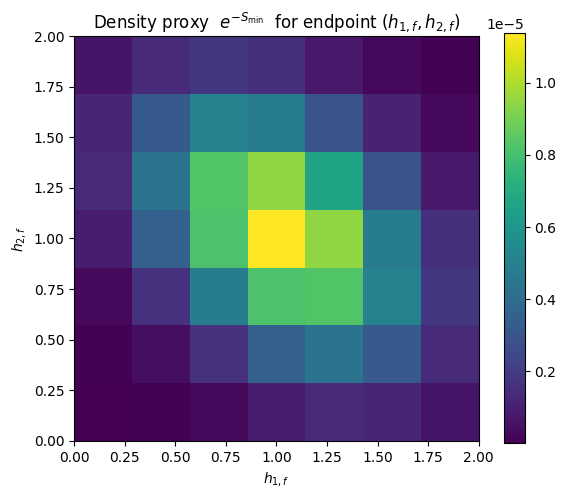

In [36]:
plt.figure(figsize=(6,5))
im = plt.imshow(
        density,
        origin='lower',
        extent=(h_min, h_max, h_min, h_max),
        aspect='equal',
        cmap='viridis')
plt.colorbar(im)
plt.xlabel(r'$h_{1,f}$')
plt.ylabel(r'$h_{2,f}$')
plt.title(r'Density proxy  $e^{-S_{\min}}$  for endpoint $(h_{1,f},h_{2,f})$')
plt.tight_layout()
plt.show()

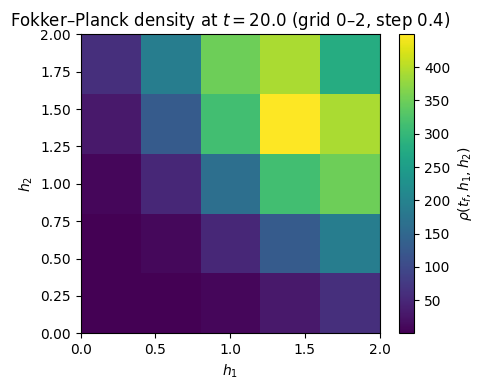

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 0.  Assumptions
# ------------------------------------------------------------------
#   axes        – tuple (h_axis, h_axis)  from fp_density_time_series_kD
#   rho_t       – array (n_snap, *grid_shape)
#   times       – snapshot times
# ------------------------------------------------------------------
assert len(axes) >= 2, "Need at least two h-axes (h1, h2)."

h_axis = axes[0]                   # both axes are identical in 2-D runs
d_h    = h_axis[1] - h_axis[0]

# range 0 … 2 with display step 0.4
h_min, h_max, disp_step = 0.0, 2.0, 0.4
disp_skip = max(1, int(round(disp_step / d_h)))   # down-sampling stride

mask = (h_axis >= h_min) & (h_axis <= h_max)
idx      = np.where(mask)[0][::disp_skip]         # indices to keep
h_disp   = h_axis[idx]

# ------------------------------------------------------------------
# 1.  Slice the final density
# ------------------------------------------------------------------
rho_final = rho_t[-1]              # last snapshot
rho_disp  = rho_final[np.ix_(idx, idx)]   # 2-D slice

# ------------------------------------------------------------------
# 2.  Plot
# ------------------------------------------------------------------
plt.figure(figsize=(5,4))
im = plt.imshow(
        rho_disp,
        origin="lower",
        extent=(h_min, h_max, h_min, h_max),
        aspect="equal",
        cmap="viridis")
plt.colorbar(im, label=r"$\rho(t_f,h_1,h_2)$")
plt.xlabel(r"$h_1$")
plt.ylabel(r"$h_2$")
plt.title(fr"Fokker–Planck density at $t={times[-1]:.1f}$ "
          r"(grid 0–2, step 0.4)")
plt.tight_layout()
plt.show()


# Optimisation of concentration

In [44]:
# =====================================================================
#  Sweep C_fixed ∈ {2,…,10}  →  ρ(t_f, h_f)   and   e^{-S_min(h_f)}
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

hf = np.array([1.7, 1.7])           # endpoint for both coordinates
h_min, h_max = axes[0][0], axes[0][-1]
assert h_min <= hf[0] <= h_max and h_min <= hf[1] <= h_max, \
    "hf must be inside the pre-computed FP grid."

# index of grid cell closest to hf
idx_hf = tuple(np.abs(ax - hfi).argmin() for ax, hfi in zip(axes, hf))

C_values   = np.arange(2, 11, dtype=float)          # 2 … 10
rho_vals   = []                                     # ρ(t_f, h_f)
expS_vals  = []                                     # e^{-S_min}

for C_fixed in C_values:
    # ---- 1. re-run Fokker–Planck with new uniform concentration -----
    def get_C(t, v, C=C_fixed):      # default arg fixes the value inside loop
        return C
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        S_mat=S_mat, get_C=get_C, T=20.0, verbose=False
    )

    # density at final snapshot & desired grid point
    rho_vals.append(rho_t[-1][idx_hf])

    # ---- 2. solve least–action BVP and compute S_min ---------------
    sol      = solve_optimal_trajectory(hf)
    S_opt, _ = compute_least_action(sol)    # returns S_opt, S_lin
    expS_vals.append(np.exp(-S_opt))

    print(f"C={C_fixed:4.1f}  ρ(tf,hf)={rho_vals[-1]:.3e}  "
          f"e^(-S)={expS_vals[-1]:.3e}")

rho_vals  = np.array(rho_vals)
expS_vals = np.array(expS_vals)





D= 0.017202216066481996
C= 2.0  ρ(tf,hf)=2.848e-01  e^(-S)=6.367e-15
D= 0.017202216066481996
C= 3.0  ρ(tf,hf)=1.458e+01  e^(-S)=2.030e-10
D= 0.017202216066481996
C= 4.0  ρ(tf,hf)=9.502e+01  e^(-S)=3.755e-08
D= 0.017202216066481996
C= 5.0  ρ(tf,hf)=2.778e+02  e^(-S)=7.590e-07
D= 0.017202216066481996
C= 6.0  ρ(tf,hf)=4.486e+02  e^(-S)=6.309e-06
D= 0.017202216066481996
C= 7.0  ρ(tf,hf)=3.234e+02  e^(-S)=5.091e-05
D= 0.017202216066481996
C= 8.0  ρ(tf,hf)=2.393e+02  e^(-S)=2.487e-04
D= 0.017202216066481996
C= 9.0  ρ(tf,hf)=1.823e+02  e^(-S)=8.472e-04
D= 0.017202216066481996
C=10.0  ρ(tf,hf)=1.427e+02  e^(-S)=2.291e-03


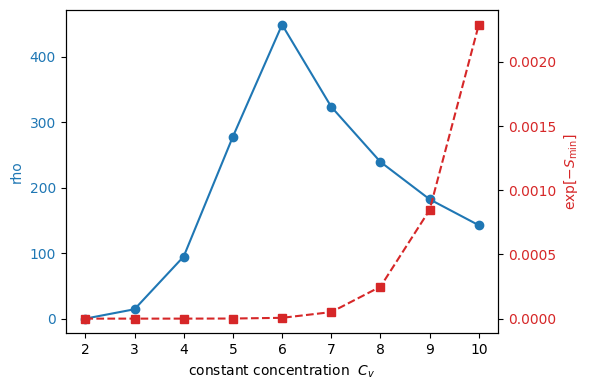

In [43]:
fig, ax1 = plt.subplots(figsize=(6,4))

ax1.set_xlabel("constant concentration  $C_v$")
ax1.set_ylabel("rho",  color="tab:blue")
ax1.plot(C_values, rho_vals, 'o-', color="tab:blue", label=r"$\rho$")
ax1.tick_params(axis='y', labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.set_ylabel(r"$\exp[-S_{\min}]$",        color="tab:red")
ax2.plot(C_values, expS_vals, 's--', color="tab:red", label=r"$e^{-S_{\min}}$")
ax2.tick_params(axis='y', labelcolor="tab:red")

fig.tight_layout(); plt.show()

In [38]:
# # ------------------------------------------------------------
# # Prerequisites already in memory
# #   S_mat, get_C
# #   times, Phi_bar, omegas        (1-D arrays, len = n_snaps)
# #   sol                           (BVP result – has .x and .y)
# # ------------------------------------------------------------
# import numpy as np
# import torch
# # ------------------------------------------------------------------
# # build Phi_bar array   (len = n_snaps = len(times))
# # ------------------------------------------------------------------
# N_h, n_A = S_mat.shape
# d_h      = axes[0][1] - axes[0][0]
# dH       = d_h ** N_h

# h_mesh   = np.meshgrid(*axes, indexing="ij")
# E_full   = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

# Phi_bar = np.zeros(len(times))
# for k, t_now in enumerate(times):
#     C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
#     Phi   = (C_vec.reshape((n_A,) + (1,)*N_h) * np.exp(E_full)).sum(axis=0)
#     rho   = rho_t[k]
#     Phi_bar[k] = (rho * Phi).sum() * dH / (rho.sum() * dH)

# # -------- constants (same as simulation) ---------------------

# N_h, n_A = S_mat.shape
# v_vec    = f_aa * mu_M * np.ones(N_h)          # drift vector

# device    = torch.device("cpu")
# S_t       = torch.tensor(S_mat, dtype=torch.float64, device=device)

# # ============================================================
# # unified Γ evaluator on arbitrary (t, h) --------------------
# # ============================================================
# def Gamma_of_t_h(t_scalar: float, h_vec_np: np.ndarray) -> float:
#     """
#     Return Γ(t, h) as Python float.
#     * t_scalar — any time within simulation window
#     * h_vec_np — numpy array shape (N_h,)
#     """
#     # --- find closest snapshot ----------------------------------------
#     idx = np.argmin(np.abs(times - t_scalar))      # nearest snapshot
#     t_now      = float(times[idx])
#     omega_now  = float(omegas[idx])
#     Phi_bar_now= float(Phi_bar[idx])

#     # C_v(t_idx)
#     C_vec = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)

#     # wrap into torch tensors
#     h_t    = torch.tensor(h_vec_np, dtype=torch.float64, device=device)
#     C_t    = torch.tensor(C_vec,   dtype=torch.float64, device=device)

#     # binding energies
#     E_v = torch.mv(S_t.T, h_t)               # (n_A,)

#     # gates
#     P_Ag_num = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
#     P_Ag     = P_Ag_num / (1. + P_Ag_num)

#     Phi  = (C_t * torch.exp(E_v / kBT)).sum()
#     P_T  = Phi / (Phi + Phi_bar_now / C_t.sum())

#     gamma_val = lam + torch.log(P_Ag) + torch.log(P_T) + omega_now
#     return gamma_val.item()

# # ============================================================
# #  compute S[trajectory]  ------------------------------------
# # ============================================================
# t_mesh = sol.x
# Y      = sol.y                       # shape (2N_h, n_nodes)
# h_path = Y[:N_h, :].T                # (n_nodes, N_h)
# h_dot  = Y[N_h:, :].T                # (n_nodes, N_h)

# # Γ(t_i, h_i)
# gamma_vals = np.array([Gamma_of_t_h(ti, hi) for ti, hi in zip(t_mesh, h_path)])

# # Lagrangian along path
# quad_term  = np.sum((h_dot - v_vec)**2, axis=1) / (2 * D)
# L_vals     = gamma_vals - quad_term

# # Action  S = -∫ L dt   (trapezoidal rule)
# S_val = -np.trapz(L_vals, t_mesh)

# print(f"Least-action value  S  =  {S_val:.6e}")


In [39]:
stop(à)

NameError: name 'stop' is not defined

epoch    0  S = 1.0048e+00


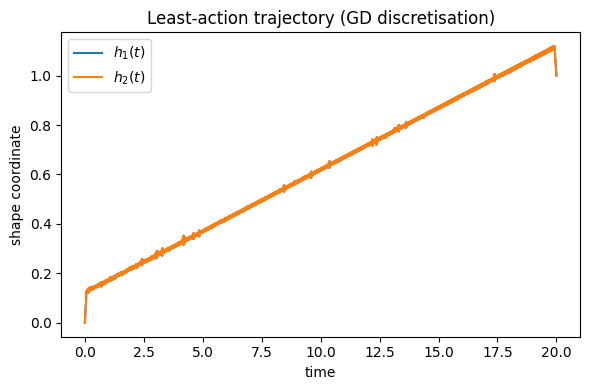

In [ ]:
# ==============================================================
# 0.  Simulation results already in memory
#     h_axes, times, rho_t, omegas = fp_density_time_series_kD(...)
#     S_mat, get_C are also defined
# ==============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt

device = torch.device("cpu")          # GPU not needed; CPU is fine

# --------------------------------------------------------------
# 1.  Model constants (must match simulation)
# --------------------------------------------------------------

v_adv           = f_aa * mu_M            # drift vector (same for each axis)

N_h             = len(h_axes)
n_snaps         = len(times)
n_A             = S_mat.shape[1]
dt              = float(times[1] - times[0])   # uniform time grid

# --------------------------------------------------------------
# 2.  Pre-compute Φ̄(t) exactly as in the solver
# --------------------------------------------------------------
# (vectorised for speed; the optimisation loop will call Γ often)
h_mesh = np.meshgrid(*h_axes, indexing="ij")
E_stack_full = np.tensordot(S_mat.T,
                            np.stack(h_mesh, axis=0),
                            axes=(1, 0))          # (n_A, …grid…)
d_h = h_axes[0][1] - h_axes[0][0]
dH  = d_h**N_h

Phi_bar = np.zeros(n_snaps)
for idx, t_now in enumerate(times):
    C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
    C_brd = C_vec.reshape((n_A,) + (1,)*N_h)
    eE    = np.exp(E_stack_full / kBT)
    Phi   = (C_brd * eE).sum(axis=0)

    rho   = rho_t[idx]
    N_pop = rho.sum() * dH
    Phi_bar[idx] = (rho * Phi).sum() * dH / N_pop

# --------------------------------------------------------------
# 3.  Build Γ(t_k, h) as a PyTorch function
# --------------------------------------------------------------
S_torch = torch.tensor(S_mat, dtype=torch.float64, device=device)

def gamma_batch(h_batch, t_idx):
    """
    h_batch : tensor (..., N_h)
    t_idx   : int   (snapshot index)
    returns : tensor (...)  (same leading dims as h_batch)
    """
    t_now   = float(times[t_idx])
    C_vec   = torch.tensor(
        [get_C(t_now, v) for v in range(n_A)],
        dtype=torch.float64, device=device
    )
    Phi_bar_now = Phi_bar[t_idx]
    omega_now   = omegas[t_idx]

    # E_v(h) for the whole batch
    E_v = torch.matmul(h_batch, S_torch)          # shape (..., n_A)

    P_Ag_num = (C_vec * torch.exp((E_v - E_a) / kBT)).sum(dim=-1)
    P_Ag     = P_Ag_num / (1. + P_Ag_num)

    Phi  = (C_vec * torch.exp(E_v / kBT)).sum(dim=-1)
    P_T  = Phi / (Phi + Phi_bar_now / C_vec.sum())

    return lam + torch.log(P_Ag) + torch.log(P_T) + omega_now
# --------------------------------------------------------------
# 4.  Optimisation variables: internal h-points
# --------------------------------------------------------------
hf=1
h0  = torch.zeros(N_h, dtype=torch.float64, device=device)
hN  = torch.full((N_h,), hf, dtype=torch.float64, device=device)

H_int = torch.linspace(0, hf, n_snaps, dtype=torch.float64,
                       device=device, requires_grad=True)  # 1-D guess
H_int = H_int.repeat(N_h, 1).t()          # shape (n_snaps, N_h)

H_int = torch.nn.Parameter(H_int)         # treat as optim. param

opt = torch.optim.Adam([H_int], lr=3e-2)

# --------------------------------------------------------------
# 5.  Training loop: minimise S[H]  -----------------------------
# --------------------------------------------------------------
n_epochs = 10
for epoch in range(n_epochs):
    # Assemble full path with fixed endpoints
    H_full = torch.vstack((h0, H_int[1:-1], hN))   # shape (n_snaps, N_h)

    # Finite-difference velocity (forward)
    v = (H_full[1:] - H_full[:-1]) / dt            # shape (n_snaps-1, N_h)

    # Γ for every node 0..N-1  (last Γ unused by forward diff)
    Gamma_nodes = []
    for k in range(n_snaps-1):
        Gamma_nodes.append(gamma_batch(H_full[k], k))
    Gamma = torch.stack(Gamma_nodes)               # shape (n_snaps-1,)

    # Action (discrete sum)
    quad  = (0.5 / D) * ((v - v_adv)**2).sum(dim=-1)   # |v - v_adv|^2
    S_val = -dt * (Gamma - quad).sum()

    opt.zero_grad()
    S_val.backward()
    opt.step()

    # Pin the endpoints after each step (robust)
    with torch.no_grad():
        H_int.data[0]  = h0
        H_int.data[-1] = hN

    if epoch % 10 == 0:
        print(f"epoch {epoch:4d}  S = {S_val.item():.4e}")

# --------------------------------------------------------------
# 6.  Visualise h_i(t)
# --------------------------------------------------------------
H_opt = H_int.detach().cpu().numpy()  # shape (n_snaps, N_h)

plt.figure(figsize=(6,4))
for i in range(min(N_h, 3)):
    plt.plot(times, H_opt[:, i], label=f'$h_{i+1}(t)$')
plt.xlabel('time')
plt.ylabel('shape coordinate')
plt.title('Least-action trajectory (GD discretisation)')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
stop()

NameError: name 'stop' is not defined

# Different antigen

  200  t=  1.00  N=  1582.8  Ω=  0.000  ⟨Γ⟩=  -0.203  ⟨h_1⟩=  0.80  ⟨h_2⟩=  0.80
  400  t=  2.00  N=  1414.2  Ω=  0.000  ⟨Γ⟩=  -0.043  ⟨h_1⟩=  1.16  ⟨h_2⟩=  1.16
  600  t=  3.00  N=  1408.5  Ω=  0.000  ⟨Γ⟩=   0.030  ⟨h_1⟩=  1.40  ⟨h_2⟩=  1.40
  800  t=  4.00  N=  1484.7  Ω=  0.000  ⟨Γ⟩=   0.074  ⟨h_1⟩=  1.60  ⟨h_2⟩=  1.60
 1000  t=  5.00  N=  1622.2  Ω=  0.000  ⟨Γ⟩=   0.103  ⟨h_1⟩=  1.76  ⟨h_2⟩=  1.76
 1200  t=  6.00  N=  1817.7  Ω=  0.000  ⟨Γ⟩=   0.125  ⟨h_1⟩=  1.90  ⟨h_2⟩=  1.90
 1400  t=  7.00  N=  2075.6  Ω=  0.000  ⟨Γ⟩=   0.141  ⟨h_1⟩=  2.03  ⟨h_2⟩=  2.03
 1600  t=  8.00  N=  2405.4  Ω=  0.000  ⟨Γ⟩=   0.154  ⟨h_1⟩=  2.14  ⟨h_2⟩=  2.14
 1800  t=  9.00  N=  2500.7  Ω=  0.165  ⟨Γ⟩=   0.000  ⟨h_1⟩=  2.24  ⟨h_2⟩=  2.24
 2000  t= 10.00  N=  2500.7  Ω=  0.000  ⟨Γ⟩=  -0.952  ⟨h_1⟩=  2.34  ⟨h_2⟩=  2.32
 2200  t= 11.00  N=  1586.2  Ω=  0.000  ⟨Γ⟩=  -0.198  ⟨h_1⟩=  3.14  ⟨h_2⟩=  1.54
 2400  t= 12.00  N=  1423.5  Ω=  0.000  ⟨Γ⟩=  -0.039  ⟨h_1⟩=  3.50  ⟨h_2⟩=  1.18
 2600  t= 13.00  N=  1423.6 

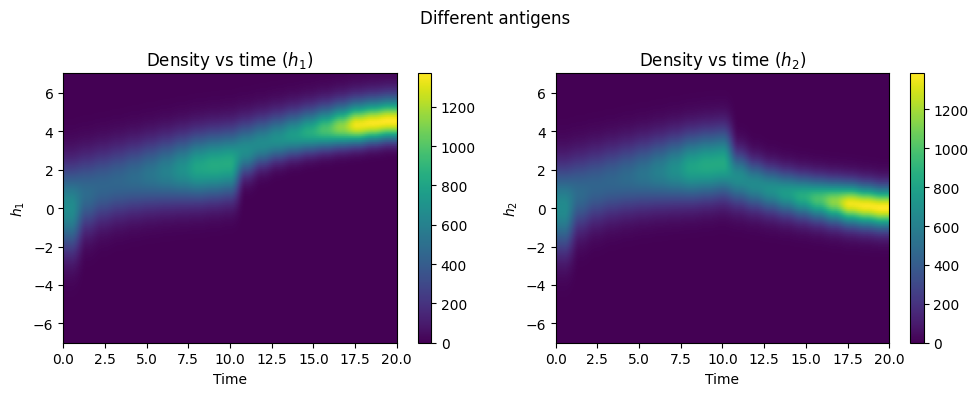

: 

In [ ]:
stop()
S_mat=np.array([[1,1],
                [1,-1],
              ])
k=S_mat.shape[0]
def get_C(t,v):
    return 10.0 if (t<10.0 and v==0) or (t>=10.0 and v==1) else 0.0

axes,times,rho_t=fp_density_time_series_kD(S_mat=S_mat,get_C=get_C, verbose=True, T=20)

# ---------------- plotting evolution per dimension ---------------
fig, axs = plt.subplots(1, k, figsize=(10, 4), sharex=True)

# Détermine masque global : points qui ont densité positive au moins une fois
rho_sum_over_time = rho_t.max(axis=0)   # shape = (m, m, …, m)
mask = rho_sum_over_time > 0            # bool grid

# Pour chaque axe h_i, on trouve les indices non nuls
for dim in range(k):
    # Intégrer sur toutes les autres dimensions
    axes_other = [i for i in range(k) if i != dim]
    rho_marg = rho_t
    for ax in sorted(axes_other, reverse=True):
        rho_marg = rho_marg.sum(axis=ax+1)  # time axis 0 → offset +1

    rho_marg *= (axes[0][1] - axes[0][0])**(k - 1)

    # Bornes y : où mask est True le long de dim
    mask_dim = mask.any(axis=tuple(i for i in range(k) if i != dim))
    idx = np.where(mask_dim)[0]
    if len(idx) == 0:
        y_min, y_max = axes[dim][0], axes[dim][-1]
    else:
        y_min, y_max = axes[dim][idx[0]], axes[dim][idx[-1]]

    im = axs[dim].imshow(rho_marg.T, origin='lower', aspect='auto',
                         extent=[times[0], times[-1], y_min, y_max])
    axs[dim].set_xlabel("Time")
    axs[dim].set_ylabel(fr"$h_{dim+1}$")
    axs[dim].set_title(f"Density vs time ($h_{dim+1}$)")
    fig.colorbar(im, ax=axs[dim])
fig.suptitle("Different antigens")

plt.tight_layout()
plt.show()
